In [4]:
pip install tabulate


Note: you may need to restart the kernel to use updated packages.


Missing Diabetes or Hypertension column. Defaulting Comorbidity to 0.

All Model Evaluation Metrics:
Model                  Accuracy    ROC AUC    Precision    Sensitivity    F1-Score
KNN                       0.67       0.663        0.616          0.388       0.476
Naive Bayes               0.847      0.907        0.812          0.784       0.798
Random Forest             0.917      0.949        0.933          0.845       0.887
Gradient Boosting         0.933      0.957        0.936          0.888       0.912
SVM                       0.687      0.768        0.729          0.302       0.427
Logistic Regression       0.887      0.947        0.88           0.819       0.848


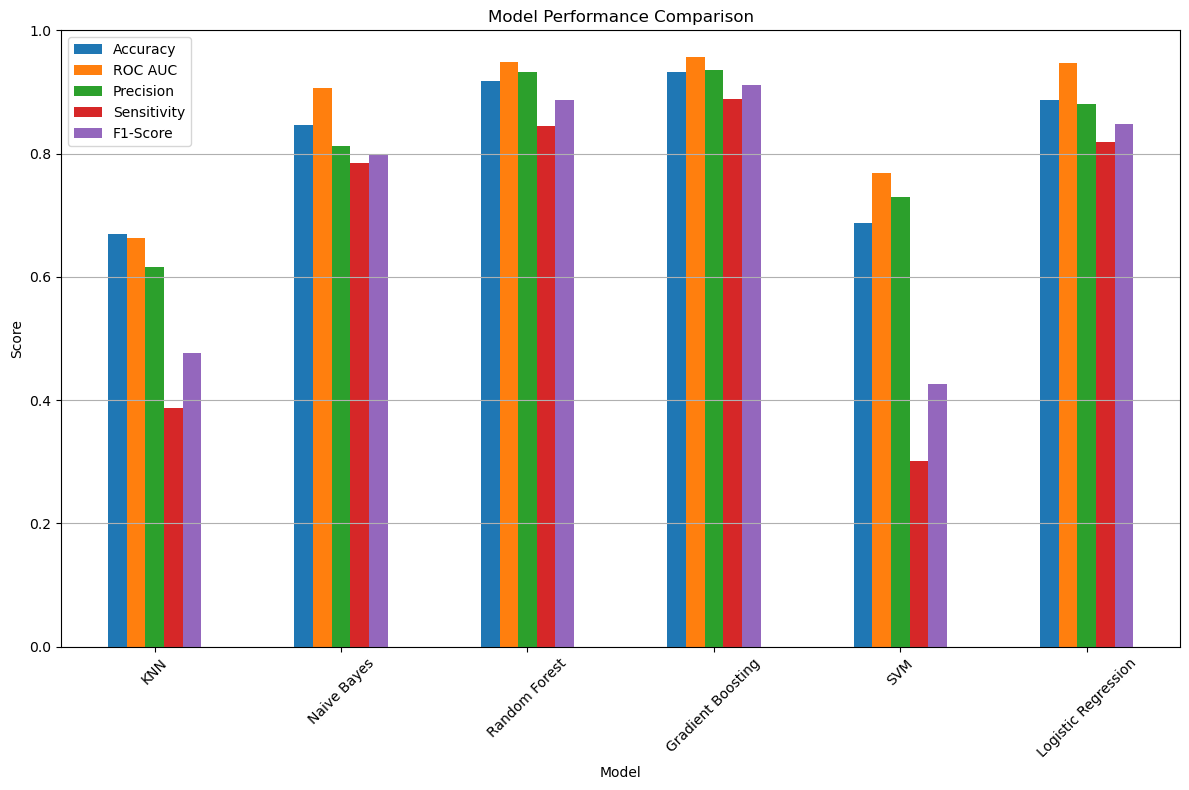


Confusion Matrix for KNN:
[[156  28]
 [ 71  45]]


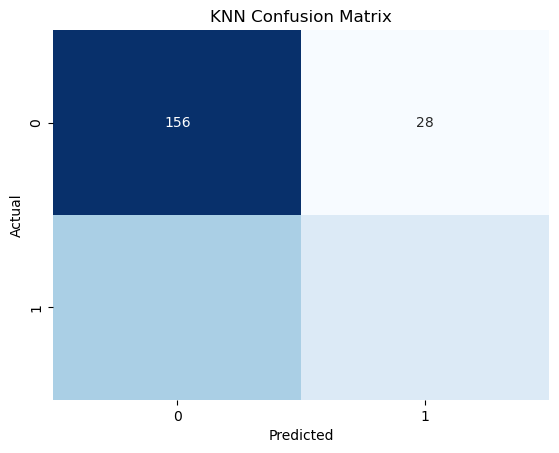


Confusion Matrix for Naive Bayes:
[[163  21]
 [ 25  91]]


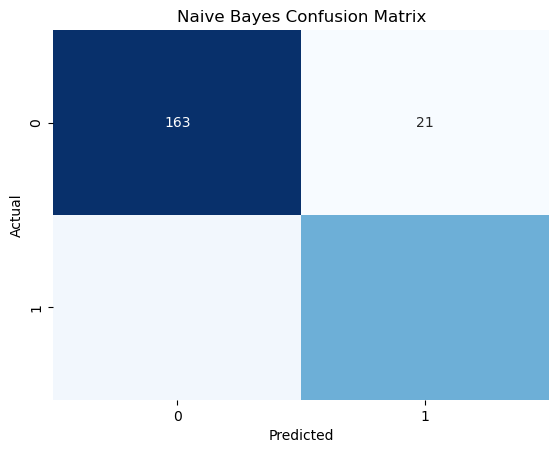


Confusion Matrix for Random Forest:
[[177   7]
 [ 18  98]]


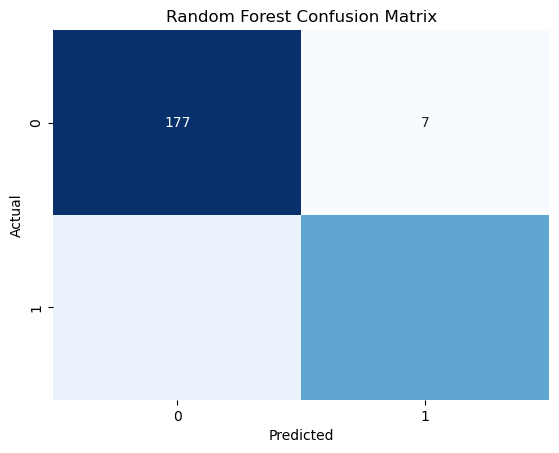


Confusion Matrix for Gradient Boosting:
[[177   7]
 [ 13 103]]


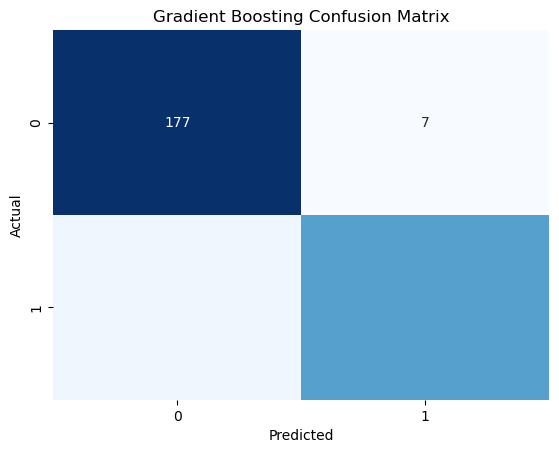


Confusion Matrix for SVM:
[[171  13]
 [ 81  35]]


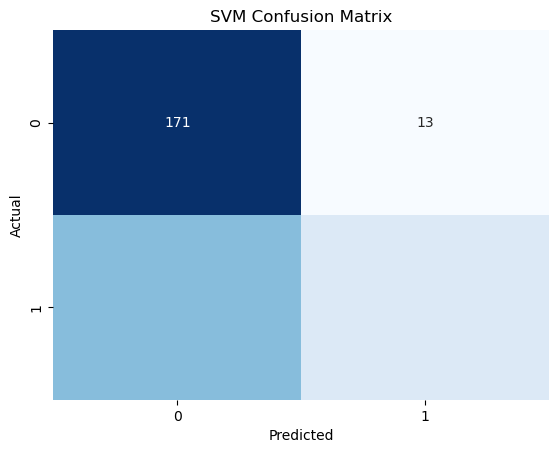


Confusion Matrix for Logistic Regression:
[[171  13]
 [ 21  95]]


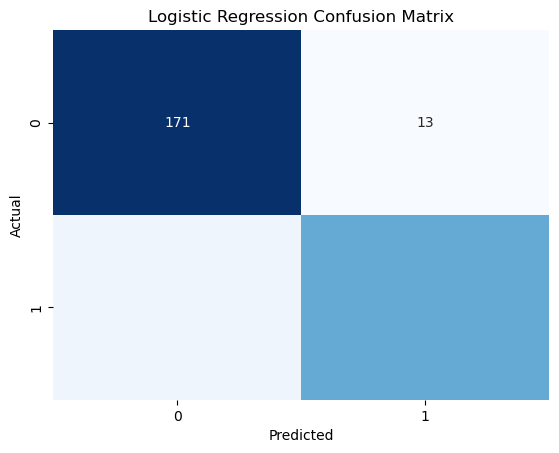


 Logistic Regression Detailed Analysis:

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       184
           1       0.88      0.82      0.85       116

    accuracy                           0.89       300
   macro avg       0.89      0.87      0.88       300
weighted avg       0.89      0.89      0.89       300

Accuracy: 0.8866666666666667
ROC AUC Score: 0.9470577211394303


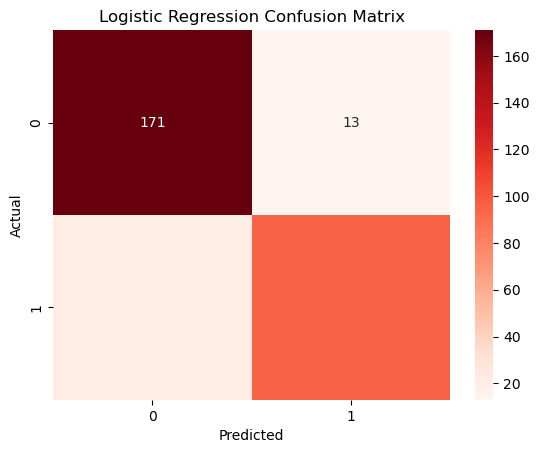

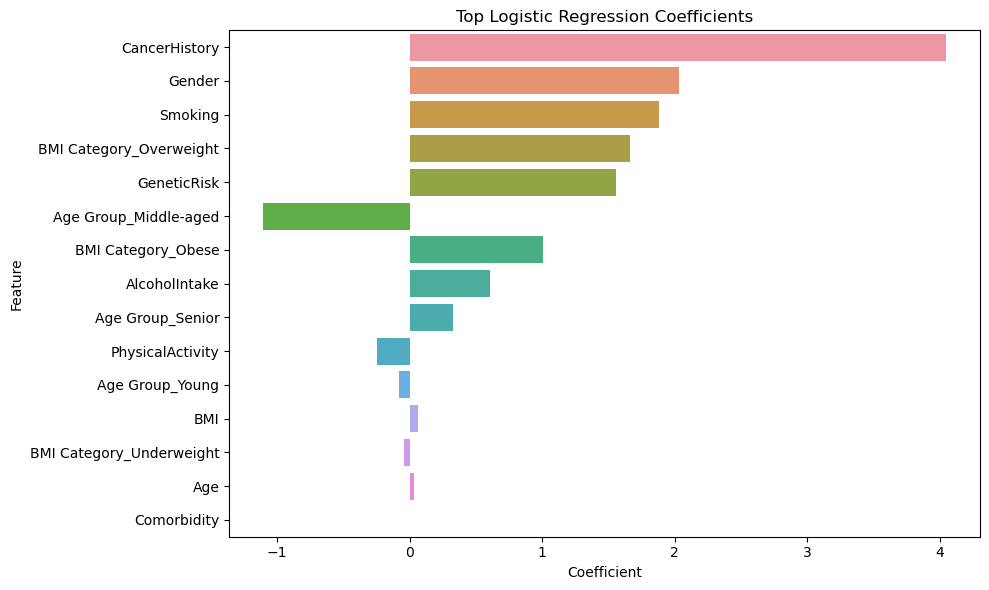


Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best RF Accuracy: 0.9133333333333333


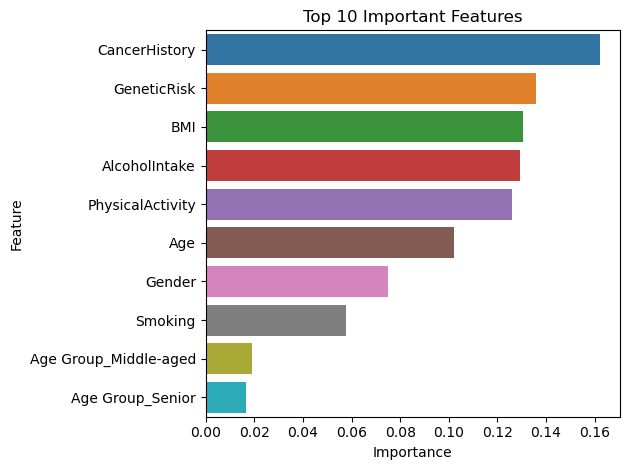

In [8]:
#fINALLY fINAL
# ==========================
# Imports
# ==========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from tabulate import tabulate

# ==========================
# Load Data
# ==========================
def load_data():
    liver_data = pd.read_csv("E:/AKHI/ACCOUNTS AK/AKHI/Research/Liver desease and liver cancer/Liver_disease_data.csv")
    cancer_data = pd.read_csv("E:/AKHI/ACCOUNTS AK/AKHI/Research/Liver desease and liver cancer/The_Cancer_data_1500_V2.csv")
    return liver_data, cancer_data

# ==========================
# Data Preprocessing
# ==========================
def preprocess_data(df):
    df.dropna(inplace=True)
    return df

# ==========================
# Feature Engineering
# ==========================
def feature_engineering(df):
    def age_group(age):
        if age < 30: return 'Young'
        elif 30 <= age < 50: return 'Middle-aged'
        elif 50 <= age < 70: return 'Senior'
        else: return 'Elderly'

    def bmi_category(bmi):
        if bmi < 18.5: return 'Underweight'
        elif 18.5 <= bmi < 25: return 'Normal'
        elif 25 <= bmi < 30: return 'Overweight'
        else: return 'Obese'

    df['Age Group'] = df['Age'].apply(age_group)
    df['BMI Category'] = df['BMI'].apply(bmi_category)

    if 'Diabetes' in df.columns and 'Hypertension' in df.columns:
        df['Comorbidity'] = ((df['Diabetes'] == 1) | (df['Hypertension'] == 1)).astype(int)
    else:
        print("Missing Diabetes or Hypertension column. Defaulting Comorbidity to 0.")
        df['Comorbidity'] = 0

    if {'ALT', 'AST', 'ALP'}.issubset(df.columns):
        df['LiverFunctionIndex'] = (df['ALT'] + df['AST']) / df['ALP']

    return df

# ==========================
# Model Training & Evaluation
# ==========================
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        "KNN": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB(),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "SVM": SVC(probability=True, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000)
    }

    performance_metrics = []
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        performance_metrics.append({
            "Model": name,
            "Accuracy": round(accuracy, 3),
            "ROC AUC": round(roc_auc, 3) if roc_auc is not None else "N/A",
            "Precision": round(report['1']['precision'], 3),
            "Sensitivity": round(report['1']['recall'], 3),
            "F1-Score": round(report['1']['f1-score'], 3)
        })

        predictions[name] = y_pred

    print("\nAll Model Evaluation Metrics:")
    print(tabulate(performance_metrics, headers="keys", tablefmt="plain", showindex=False))

    return predictions, pd.DataFrame(performance_metrics)

# ==========================
# Logistic Regression Analysis
# ==========================
def analyze_logistic_regression(X_train, X_test, y_train, y_test, feature_names):
    print("\n Logistic Regression Detailed Analysis:")
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.title("Logistic Regression Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0]
    }).sort_values(by='Coefficient', key=np.abs, ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature')
    plt.title("Top Logistic Regression Coefficients")
    plt.tight_layout()
    plt.show()

# ==========================
# Hyperparameter Tuning
# ==========================
def tune_random_forest(X_train, y_train):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_, grid_search.best_params_

# ==========================
# Plotting Utilities
# ==========================
def plot_performance(performance_df):
    performance_df.set_index('Model').plot(kind='bar', figsize=(12, 8))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.show()

def plot_confusion(predictions, y_test):
    for model_name, preds in predictions.items():
        cm = confusion_matrix(y_test, preds)
        print(f"\nConfusion Matrix for {model_name}:")
        print(cm)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'{model_name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

def plot_feature_importance(model, features):
    if hasattr(model, 'feature_importances_'):
        importance_df = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
        importance_df.sort_values(by='Importance', ascending=False, inplace=True)

        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title('Top 10 Important Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Feature importance is not available for this model.")

# ==========================
# Main Driver
# ==========================
if __name__ == "__main__":
    liver_data, cancer_data = load_data()
    cancer_data = preprocess_data(cancer_data)
    cancer_data = feature_engineering(cancer_data)

    X = cancer_data.drop(columns=['Diagnosis'])
    y = cancer_data['Diagnosis']
    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    predictions, performance_df = train_and_evaluate_models(X_train, X_test, y_train, y_test)
    plot_performance(performance_df)
    plot_confusion(predictions, y_test)

    #  Analyze Logistic Regression Separately
    analyze_logistic_regression(X_train, X_test, y_train, y_test, X.columns)

    # Random Forest Tuning
    best_model, best_params = tune_random_forest(X_train, y_train)
    print("\nBest Random Forest Parameters:", best_params)
    best_preds = best_model.predict(X_test)
    print("Best RF Accuracy:", accuracy_score(y_test, best_preds))
    plot_feature_importance(best_model, X.columns)
